In [1]:
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import torch
import torch.nn as nn
import pandas as pd
target_dir = "./training2017/"

In [2]:
# count the number of .mat files in the target directory
num_files = len([name for name in os.listdir(target_dir) if name.endswith('.mat')])
print(f"Number of .mat files in {target_dir}: {num_files}")

Number of .mat files in ./training2017/: 8528


In [3]:
#load the first .mat file
mat_file = os.path.join(target_dir, 'A00001.mat')
print(f"Loading {mat_file}...")
mat_data = loadmat(mat_file)
print("Loaded data keys:", mat_data.keys())
print("Loaded data shape:", mat_data['val'].shape)

# Extract the 'val' variable from the loaded .mat file
val = mat_data['val']
print(val)

Loading ./training2017/A00001.mat...
Loaded data keys: dict_keys(['val'])
Loaded data shape: (1, 9000)
[[-127 -162 -197 ...  -18  -22  -21]]


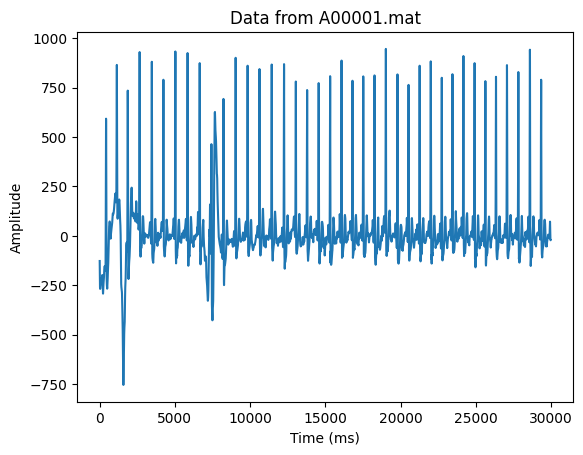

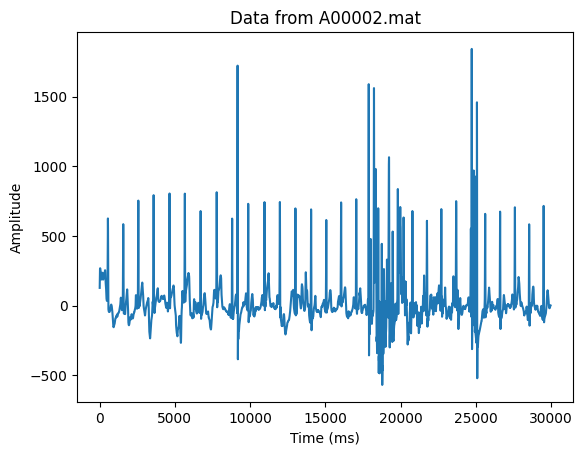

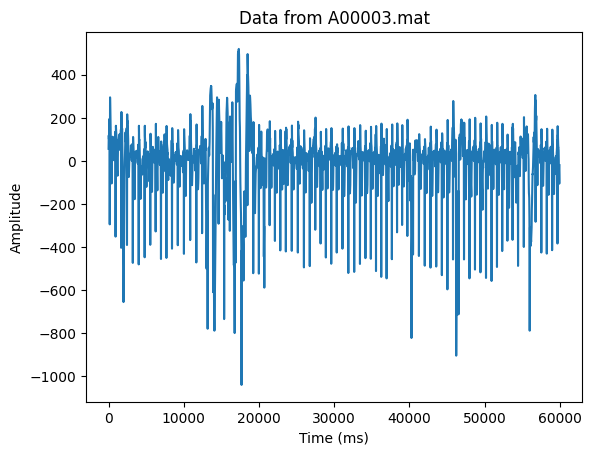

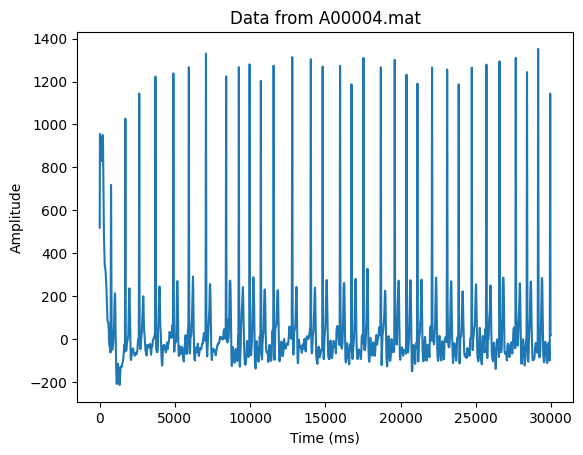

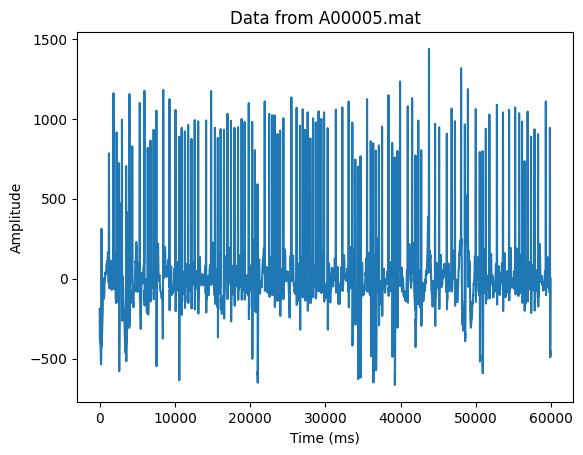

In [4]:
# graph the first 10 .mat files in the target directory
for i, filename in enumerate(os.listdir(target_dir)):
    if filename.endswith('.mat'):
        data = loadmat(os.path.join(target_dir, filename))
        plt.figure()
        plt.title(f"Data from {filename}")
        y = data['val'][0, :].flatten()
        x = np.arange(len(y)) * 3.33  # The sampling rate is 300 Hz, adjust the time axis accordingly
        plt.plot(x, y)
        plt.xlabel('Time (ms)')
        plt.ylabel('Amplitude')
        plt.show()
        if i == 9:
            break
        

In [5]:
reference = pd.read_csv(target_dir + 'reference.csv', header=None)
reference.head()

,0,1
0,A00001,N
1,A00002,N
2,A00003,N
3,A00004,A
4,A00005,A


<Axes: xlabel='1', ylabel='Count'>

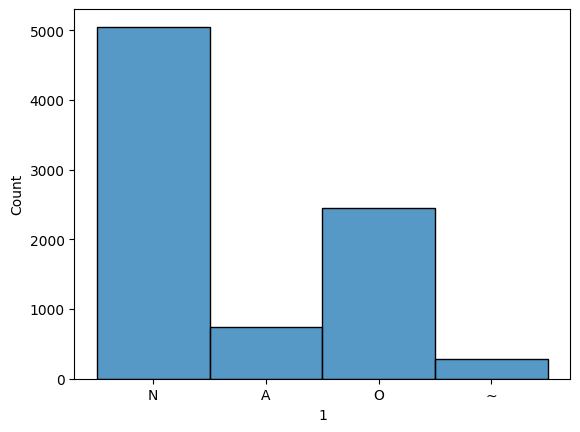

In [6]:
#plot the distribution of the reference values
sns.histplot(reference[1])

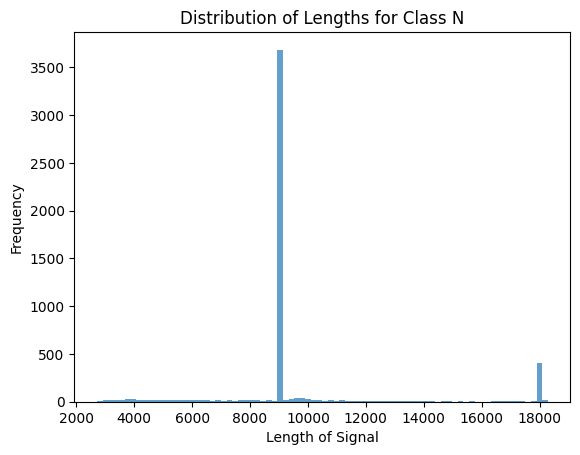

Class N: Mean Length = 9629.492475247525, Std Length = 2990.6341997104946


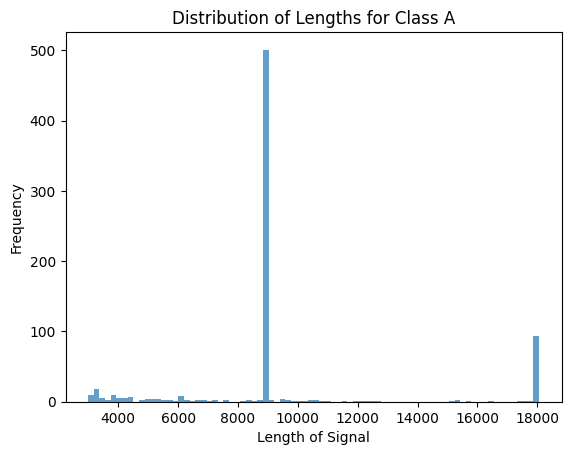

Class A: Mean Length = 9631.337398373984, Std Length = 3703.4953805639902


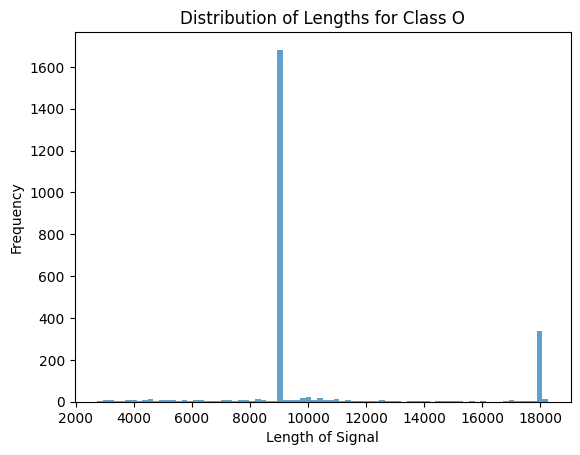

Class O: Mean Length = 10318.209283387621, Std Length = 3516.222560568554


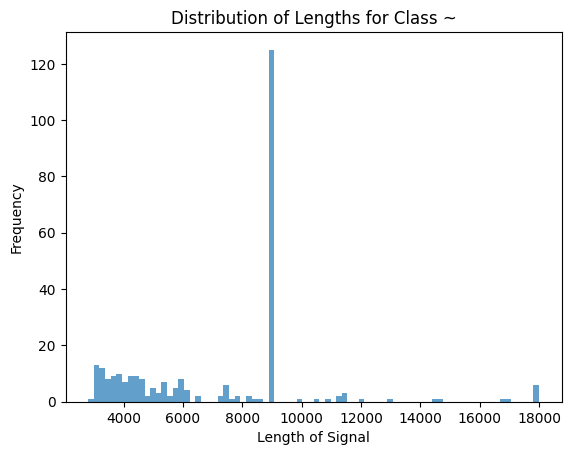

Class ~: Mean Length = 7264.55985915493, Std Length = 3092.6005056039735


In [7]:
# for each class, plot the distribution of the lenth of the signal
for i in reference[1].unique():
    class_data = reference[reference[1] == i]
    #read the .mat files for the class
    class_files = [os.path.join(target_dir, f'{f}.mat') for f in class_data[0]]
    lengths = []
    for file in class_files:
        data = loadmat(file)
        lengths.append(data['val'][0, :].flatten().shape[0])
    plt.figure()
    plt.hist(lengths, bins=80, alpha=0.7, label=f'Class {i}')
    plt.xlabel('Length of Signal')
    plt.ylabel('Frequency')
    plt.title(f'Distribution of Lengths for Class {i}')
    plt.show()
    # calculate the mean and std of the lengths
    mean_length = np.mean(lengths)
    std_length = np.std(lengths)
    print(f"Class {i}: Mean Length = {mean_length}, Std Length = {std_length}")

In [8]:
#pad the signals to the same length
def pad_signal(signal, target_length):
    
    # Check if the signal is 2D
    if len(signal.shape) == 2:
        # flatten the signal to 1D
        signal = signal.flatten()
    if signal.shape[0] < target_length:
        # Pad with zeros
        padding = np.zeros((target_length - signal.shape[0],))
        padded_signal = np.concatenate((signal, padding), axis=0)
    else:
        # Truncate the signal
        padded_signal = signal[:target_length]
    return padded_signal


# Define the target length to be the maximum length
target_length = max(lengths)
print(f"Target length for padding: {target_length}")

Target length for padding: 18000


In [9]:
# Load the data and pad the signals
data = []
#read the .mat files for the class
all_files = [os.path.join(target_dir, f'{f}.mat') for f in reference[0]]

# load all of the data into a list
for file in all_files:
    data.append(loadmat(file)['val'][0, :].flatten())

# pad the signals to the same length
padded_data = [pad_signal(signal, target_length) for signal in data]

# Convert to numpy array
padded_data = np.array(padded_data)
print(f"Padded data shape: {padded_data.shape}")

# convert the labels to a numpy array
labels = reference[1].values
# map the labels to integers
label_map = {'N': 0, 'O': 1, 'A': 2, '~': 3}
labels = np.array([label_map[label] for label in labels])


# Convert to PyTorch tensors
padded_data_tensor = torch.tensor(padded_data, dtype=torch.float32)
labels_tensor = torch.tensor(labels, dtype=torch.long)
print(f"Padded data tensor shape: {padded_data_tensor.shape}")
print(f"Labels tensor shape: {labels_tensor.shape}")

total_samples = padded_data_tensor.shape[0]

# Calculate how many samples make up 10%
samples_to_extract = int(total_samples * 0.1)

# Create random indices (without replacement) for the 10%
random_indices = np.random.choice(total_samples, samples_to_extract, replace=False)

# Extract the 10% using the random indices
val_data = padded_data_tensor[random_indices]
val_labels = labels_tensor[random_indices]

# Verify the shape
print(f"Extracted data shape: {val_data.shape}")
print(f"Extracted labels shape: {val_labels.shape}")

# remove this 10% from the original data to get the remaining 90%:
remaining_indices = np.array([i for i in range(total_samples) if i not in random_indices])
remaining_data = padded_data_tensor[remaining_indices]
remaining_labels = labels_tensor[remaining_indices]

print(f"Remaining data shape: {remaining_data.shape}")
print(f"Remaining labels shape: {remaining_labels.shape}")

Padded data shape: (8528, 18000)
Padded data tensor shape: torch.Size([8528, 18000])
Labels tensor shape: torch.Size([8528])
Extracted data shape: torch.Size([852, 18000])
Extracted labels shape: torch.Size([852])
Remaining data shape: torch.Size([7676, 18000])
Remaining labels shape: torch.Size([7676])


In [10]:
# start the ml pipeline
from sklearn.model_selection import train_test_split


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(remaining_data, remaining_labels, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}, Training labels shape: {y_train.shape}")
print(f"Testing data shape: {X_test.shape}, Testing labels shape: {y_test.shape}")

Training data shape: torch.Size([6140, 18000]), Training labels shape: torch.Size([6140])
Testing data shape: torch.Size([1536, 18000]), Testing labels shape: torch.Size([1536])


In [11]:
# define a dataset class and a dataloader
from torch.utils.data import Dataset, DataLoader
class ECGDataset(Dataset):
    def __init__(self, data, labels):
        self.data = data
        self.labels = labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

In [12]:
# Define a simple neural network model
class StartNN(nn.Module):
    def __init__(self, input_size, num_classes):
        super(StartNN, self).__init__()
        self.block = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.block(x)
        return x
    

In [13]:
class ConvNN(nn.Module):
    def __init__(self, input_size, num_classes):
        super(ConvNN, self).__init__()
        self.convo_block = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Conv1d(16, 32, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )

        self.output_block = nn.Sequential(
            nn.Linear(32 * (input_size // 4), 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.convo_block(x)
        x = x.view(x.size(0), -1)
        x = self.output_block(x)
        return x

In [14]:
class SkipConnection(nn.Module):
    def __init__(self, input_size, output_size):
        super(SkipConnection, self).__init__()
        self.block = nn.Sequential(
            nn.Linear(input_size, input_size//2),
            nn.ReLU(),
            nn.Linear(input_size//2, input_size//4),
            nn.ReLU(),
            nn.Linear(input_size//4, output_size)
        )

    def forward(self, x):
        skip = x
        x = self.block(x)
        x += skip
        return x
    
class FinalNN(nn.Module):
    def __init__(self, input_size, num_classes):
        super(FinalNN, self).__init__()
        self.skip1 = SkipConnection(input_size, input_size//2)
        self.skip2 = SkipConnection(input_size//2, input_size//4)

    def forward(self, x):
        x = self.skip1(x)
        x = self.skip2(x)
        return x

In [15]:
# Define the model, loss function, and optimizer
input_size = target_length
num_classes = len(label_map)
# model = StartNN(input_size, num_classes)
model = ConvNN(input_size, num_classes)
print(model)

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)

ConvNN(
  (convo_block): Sequential(
    (0): Conv1d(1, 16, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (output_block): Sequential(
    (0): Linear(in_features=144000, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=4, bias=True)
  )
)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Using device: {device}")

# Training loop
num_epochs = 10
batch_size = 32
train_loss_history = []
test_loss_history = []

train_dataset = ECGDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataset = ECGDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
val_dataset = ECGDataset(val_data, val_labels)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

for epoch in range(num_epochs):
    epch_loss = 0.0
    model.train()
    for batch in train_loader:
        X_batch, y_batch = batch
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch.unsqueeze(1))
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        epch_loss += loss.item()
    epch_loss /= len(train_loader)
    train_loss_history.append(epch_loss)
    print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {epch_loss}")

    # Testing loop
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in test_loader:
            X_batch, y_batch = batch
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch.unsqueeze(1))
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
    val_loss /= len(test_loader)
    test_loss_history.append(val_loss)

    print(f"Epoch {epoch + 1}/{num_epochs}, Test Loss: {val_loss}")

# Plot the training and testing loss
plt.figure(figsize=(10, 5))
plt.plot(train_loss_history, label='Training Loss')
plt.plot(test_loss_history, label='Testing Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Testing Loss')
plt.legend()
plt.show()

Using device: cpu
Epoch 1/10, Loss: 0.1051881710930805
Epoch 1/10, Test Loss: 3.4059661080439887
Epoch 2/10, Loss: 0.06956056867541822
Epoch 2/10, Test Loss: 3.610988572239876


Accuracy of the model on the validation set: 45.07%
              precision    recall  f1-score   support

           0       0.61      0.54      0.58       527
           1       0.28      0.39      0.32       231
           2       0.10      0.08      0.09        64
           3       0.20      0.10      0.13        30

    accuracy                           0.45       852
   macro avg       0.30      0.28      0.28       852
weighted avg       0.47      0.45      0.46       852



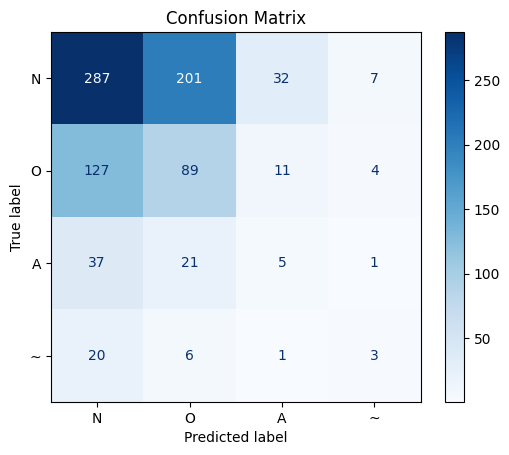

In [17]:
from sklearn.metrics import classification_report, f1_score  
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Evaluation loop
y_pred = []
y_true = []
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for batch in val_loader:
        X_batch, y_batch = batch
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch.unsqueeze(1))
        _, predicted = torch.max(outputs.data, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()
        y_pred.extend(predicted.cpu().numpy())
        y_true.extend(y_batch.cpu().numpy())
accuracy = 100 * correct / total
print(f"Accuracy of the model on the validation set: {accuracy:.2f}%")

# Compute the confusion matrix, f1 score for each class, and the classification report
confusion = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

print(report)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion, display_labels=label_map.keys())
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()